In [1]:
# Cell 1: Setup and Data Loading
import sys
import pandas as pd
from pathlib import Path

# Point Python to the project root so it can find the 'src' folder
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src import data_loader

# Load the raw data using the module
raw_csv_path = PROJECT_ROOT / "data" / "raw" / "ontario_housing.csv"
df = data_loader.load_from_csv(raw_csv_path)

print(f"Loaded {df.shape[0]:,} rows and {df.shape[1]:,} columns.")

Loaded 414 rows and 34 columns.


In [2]:
# Cell 2: Data Cleaning and Saving to Processed Folder
import os
from src import preprocessing

# The assignment focuses on these two columns
X_col = 'average_purchase_price_of_a_detached_house'
y_col = 'affordable_purchase_price_of_a_detached_house'

# Clean the commas and convert to numeric using the module
# Note: For full EDA we want all columns, so we apply the logic broadly
for col in df.columns:
    if col not in {"municipality", "tier", "region"} and not col.startswith("threshold_applied_for_"):
        df[col] = pd.to_numeric(df[col].astype(str).str.replace(",", "", regex=False), errors="coerce")

# Create the processed directory if it doesn't exist
processed_dir = PROJECT_ROOT / "data" / "processed"
os.makedirs(processed_dir, exist_ok=True)

# Save the cleaned dataset for the modeling notebook to use later
processed_path = processed_dir / "ontario_housing_processed.csv"
df.to_csv(processed_path, index=False)

print(f"Cleaned dataset saved to: {processed_path}")

Cleaned dataset saved to: c:\Users\Davisen\Documents\GitHub\CSCN8010-LinearRegressionArchitecture_Workshop\data\processed\ontario_housing_processed.csv


In [3]:
# Cell 3: Basic Summary Statistics
print(f"Dataset shape: {df.shape[0]:,} rows and {df.shape[1]:,} columns")
print("First five rows:")
display(df.head())

print("\nData quality by column:")
quality_summary = pd.DataFrame({
    "data_type": df.dtypes.astype(str),
    "missing_values": df.isna().sum(),
    "missing_percent": (df.isna().mean() * 100).round(1),
    "unique_values": df.nunique(),
})
display(quality_summary)

print("\nSummary statistics for numeric columns:")
display(df.describe().T.round(1))

Dataset shape: 414 rows and 34 columns
First five rows:


,id,municipality,tier,region,affordable_purchase_price_of_a_detached_house,affordable_purchase_price_of_a_semi_detached_house,affordable_purchase_price_of_a_row_townhouse,affordable_purchase_price_of_a_condominium_apartment,purchase_price_based_on_income,ninety_per_cent_of_average_purchase_price_detached,...,affordable_monthly_rent_of_a_3_bedroom_unit,rent_based_on_income,average_market_rent_of_a_bachelor_unit,average_market_rent_of_a_1_bedroom_unit,average_market_rent_of_a_2_bedroom_unit,average_market_rent_of_a_3_bedroom_unit,threshold_applied_for_a_bachelor_unit_and_substitution,threshold_applied_for_a_1_bedroom_unit_and_substitution,threshold_applied_for_a_2_bedroom_unit_and_substitution,threshold_applied_for_a_3_bedroom_unit_and_substitution
0,1,Addington Highlands Tp,LT,Eastern,260000,260000,260000,260000,260000,441000,...,1580,1580,955,1206,1298,2142,Rent; CD,Rent; CD,Rent; CD,Income; Base
1,2,Adelaide-Metcalfe Tp,LT,Western,481200,441000,468000,423000,481200,747000,...,1976,2570,1079,1381,1654,1976,Rent; CD,Rent; CD,Rent; CD,Rent; CD
2,3,Adjala-Tosorontio Tp,LT,Central,539400,539400,539400,539400,539400,1071000,...,1833,2140,1003,1475,1651,1833,Rent; CD,Rent; CD,Rent; CD,Rent; CD
3,4,Admaston-Bromley Tp,LT,Eastern,407400,369000,387000,279000,407400,468000,...,1592,2170,1281,1140,1312,1592,Rent; Region,Rent; CD,Rent; CD,Rent; CD
4,5,Ajax T,LT,Central,535500,535500,535500,504000,535500,981000,...,1870,2540,1330,1216,1727,1870,Rent; CD,Rent; Base,Rent; Base,Rent; Base



Data quality by column:


,data_type,missing_values,missing_percent,unique_values
id,int64,0,0.0,414
municipality,object,0,0.0,414
tier,object,0,0.0,2
region,object,0,0.0,5
affordable_purchase_price_of_a_detached_house,int64,0,0.0,121
affordable_purchase_price_of_a_semi_detached_house,int64,0,0.0,107
affordable_purchase_price_of_a_row_townhouse,int64,0,0.0,115
affordable_purchase_price_of_a_condominium_apartment,int64,0,0.0,112
purchase_price_based_on_income,int64,0,0.0,101
ninety_per_cent_of_average_purchase_price_detached,int64,0,0.0,123



Summary statistics for numeric columns:


,count,mean,std,min,25%,50%,75%,max
id,414.0,207.5,119.7,1.0,104.2,207.5,310.8,414.0
affordable_purchase_price_of_a_detached_house,414.0,378373.4,89549.7,144000.0,318200.0,368600.0,430700.0,667400.0
affordable_purchase_price_of_a_semi_detached_house,414.0,350125.4,101220.2,171000.0,261000.0,351000.0,414225.0,667400.0
affordable_purchase_price_of_a_row_townhouse,414.0,362353.9,95712.5,153000.0,295375.0,351000.0,419100.0,667400.0
affordable_purchase_price_of_a_condominium_apartment,414.0,367039.9,79017.4,195600.0,306000.0,345300.0,405000.0,644100.0
purchase_price_based_on_income,414.0,396555.1,80275.3,195600.0,341500.0,384200.0,446200.0,667400.0
ninety_per_cent_of_average_purchase_price_detached,414.0,616565.2,313011.4,144000.0,396000.0,558000.0,747000.0,2187000.0
ninety_per_cent_of_average_purchase_price_semi_detached,414.0,422891.3,181544.4,171000.0,261000.0,387000.0,513000.0,1215000.0
ninety_per_cent_of_average_purchase_price_row_townhouse,414.0,469521.7,246381.3,153000.0,324000.0,459000.0,567000.0,4005000.0
ninety_per_cent_of_average_purchase_price_condo_apt,414.0,455500.0,174935.4,198000.0,324000.0,405000.0,558000.0,1791000.0


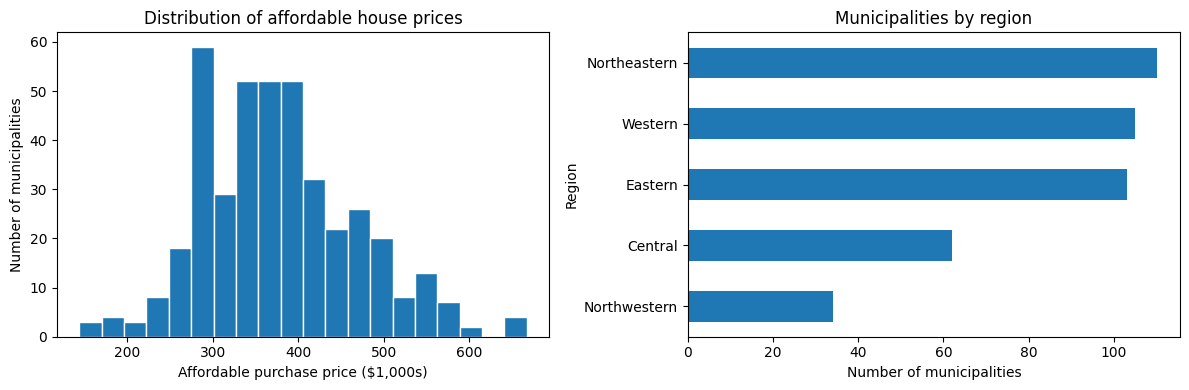

In [4]:
# Cell 4: Visual Checks
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
axes[0].hist(df[y_col] / 1_000, bins=20, edgecolor="white")
axes[0].set_xlabel("Affordable purchase price ($1,000s)")
axes[0].set_ylabel("Number of municipalities")
axes[0].set_title("Distribution of affordable house prices")

# Bar Chart
df["region"].value_counts().sort_values().plot.barh(ax=axes[1])
axes[1].set_xlabel("Number of municipalities")
axes[1].set_ylabel("Region")
axes[1].set_title("Municipalities by region")

plt.tight_layout()
plt.show()

Missing values in the target: 0

Average affordable detached-house price by region ($):
              count      mean    median
region                                 
Central          62  457944.0  463700.0
Eastern         103  372735.0  372500.0
Northeastern    110  316146.0  303350.0
Northwestern     34  300368.0  279550.0
Western         105  427370.0  411300.0


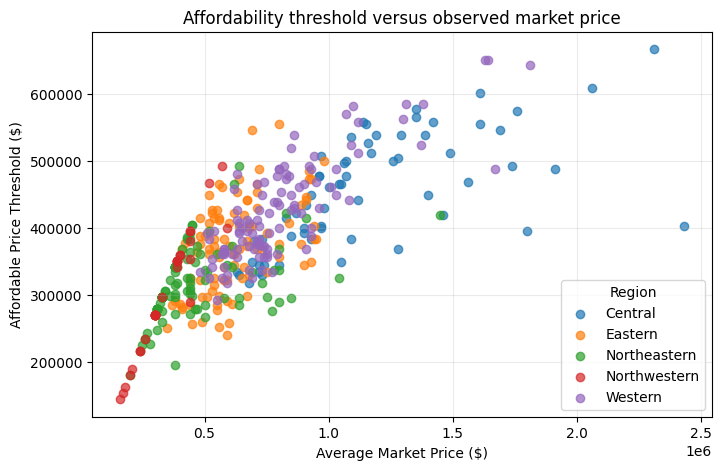

In [5]:
# Cell 5: Regional Comparisons
print(f"Missing values in the target: {int(df[y_col].isna().sum())}")
print("\nAverage affordable detached-house price by region ($):")
print(df.groupby("region")[y_col].agg(["count", "mean", "median"]).round(0))

plt.figure(figsize=(8, 5))
for region, group in df.groupby("region"):
    plt.scatter(
        group[X_col],
        group[y_col],
        alpha=0.7,
        label=region,
    )
plt.xlabel("Average Market Price ($)")
plt.ylabel("Affordable Price Threshold ($)")
plt.title("Affordability threshold versus observed market price")
plt.legend(title="Region")
plt.grid(alpha=0.25)
plt.show()